In [1]:
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score
)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score

df = pd.read_csv('high_risk_pregnancy_realistic_2000 (1).csv')

In [2]:
import joblib

x_train_smote = joblib.load('x_train_smote.pkl')
y_train_smote = joblib.load('y_train_smote.pkl')
x_test_scaled = joblib.load('x_test_scaled.pkl')
y_test        = joblib.load('y_test.pkl')

In [3]:
svm_model = SVC(
    kernel='rbf',
    probability=True,
    random_state=20
)

In [4]:
svm_model.fit(x_train_smote, y_train_smote)

SVC(probability=True, random_state=20)

In [5]:
svm_pred = svm_model.predict(x_test_scaled)

In [6]:
svm_prob = svm_model.predict_proba(x_test_scaled)[:, 1]
print(svm_prob)

[1.48372729e-01 1.53748149e-04 1.49080582e-02 6.80190132e-02
 8.65535349e-02 1.74080906e-02 6.51547921e-04 6.40773966e-02
 2.17805130e-02 6.95143723e-02 2.09153112e-01 1.38311840e-01
 2.16811339e-02 2.36707395e-02 9.81207429e-02 1.57516142e-02
 2.87786187e-03 6.79664430e-02 5.51767155e-03 2.74738578e-02
 4.50855175e-01 6.85844132e-02 3.61781963e-01 1.54466294e-02
 3.00995440e-01 4.04717173e-03 1.88879910e-02 1.08708697e-02
 6.23894611e-02 3.39508576e-02 5.51362430e-02 2.51880145e-01
 5.06541985e-03 1.12818858e-01 3.59356855e-02 6.56179060e-03
 1.25847862e-03 1.96221518e-04 4.12095046e-02 5.09132785e-02
 8.88191578e-01 1.06154328e-03 3.57792564e-03 5.95235216e-01
 5.34738762e-02 2.02753247e-03 1.68155695e-02 2.82536937e-02
 7.12201416e-03 1.24238819e-02 1.82769427e-04 7.24144426e-04
 9.59073645e-04 7.25094409e-01 7.17017537e-02 8.73865083e-02
 2.70621160e-01 4.80552035e-01 2.45815476e-01 4.39626291e-02
 6.94897643e-03 1.68894958e-02 1.13619349e-02 9.12697773e-02
 6.38960999e-04 3.508071

In [7]:
svm_accuracy = accuracy_score(y_test, svm_pred)
print("SVM Accuracy:", round(svm_accuracy, 4))

SVM Accuracy: 0.7845


In [8]:
print("Classification Report\n")
print(classification_report(y_test, svm_pred))

Classification Report

              precision    recall  f1-score   support

           0       0.85      0.90      0.87       330
           1       0.32      0.22      0.26        69

    accuracy                           0.78       399
   macro avg       0.58      0.56      0.57       399
weighted avg       0.76      0.78      0.77       399



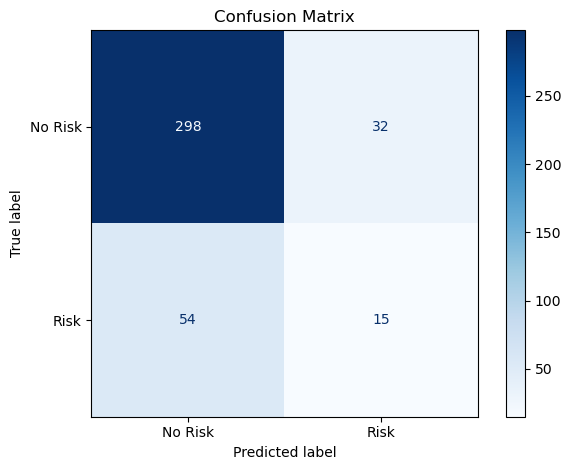

In [9]:
ConfusionMatrixDisplay.from_predictions(y_test, svm_pred, display_labels=['No Risk', 'Risk'], cmap='Blues')
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

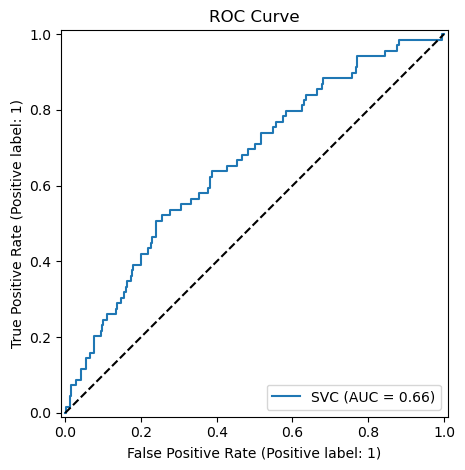

In [10]:
RocCurveDisplay.from_estimator(svm_model, x_test_scaled, y_test)
plt.title('ROC Curve')
plt.plot([0, 1], [0, 1], 'k--')
plt.tight_layout()
plt.show()

In [11]:
print('ROC-AUC Score:', roc_auc_score(y_test, svm_prob).round(4))

ROC-AUC Score: 0.6602


In [12]:
precision = precision_score(y_test, svm_pred)
recall    = recall_score(y_test, svm_pred)
f1        = f1_score(y_test, svm_pred)

print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))

Precision: 0.3191
Recall   : 0.2174
F1 Score : 0.2586


In [13]:
train_pred = svm_model.predict(x_train_smote)
print("Train Accuracy:", round(accuracy_score(y_train_smote, train_pred), 4))
print("Test Accuracy :", round(svm_accuracy, 4))

Train Accuracy: 0.9597
Test Accuracy : 0.7845


In [14]:
param_grid = {
    'C':      [0.1, 1, 10],
    'kernel': ['rbf', 'linear'],
    'gamma':  ['scale', 'auto']
}

grid_search = GridSearchCV(
    SVC(probability=True, random_state=20),
    param_grid, cv=5, scoring='roc_auc', n_jobs=-1
)
grid_search.fit(x_train_smote, y_train_smote)

GridSearchCV(cv=5, estimator=SVC(probability=True, random_state=20), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10], 'gamma': ['scale', 'auto'],
                         'kernel': ['rbf', 'linear']},
             scoring='roc_auc')

In [15]:
print("Best Params:", grid_search.best_params_)
best_model = grid_search.best_estimator_

Best Params: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}


In [16]:
best_pred = best_model.predict(x_test_scaled)
best_prob = best_model.predict_proba(x_test_scaled)[:, 1]
print("Best Model Accuracy:", round(accuracy_score(y_test, best_pred), 4))
print("Best Model ROC-AUC :", roc_auc_score(y_test, best_prob).round(4))

Best Model Accuracy: 0.7619
Best Model ROC-AUC : 0.6224


In [17]:
cv_scores = cross_val_score(svm_model, x_train_smote, y_train_smote, cv=5, scoring='roc_auc')
print("CV ROC-AUC Scores:", cv_scores.round(4))
print("Mean:", cv_scores.mean().round(4), "| Std dev:", cv_scores.std().round(4))

CV ROC-AUC Scores: [0.9169 0.9783 0.9797 0.9864 0.9788]
Mean: 0.968 | Std dev: 0.0257


In [18]:
joblib.dump(svm_model, 'svm_model.pkl')
print("Model saved.")

Model saved.
